# Discharge Plotting


In [1]:
import matplotlib.pyplot as plt
import os
from TPED.projects.discharge_tools.src.discharge_data import DischargeData
from TPED.projects.discharge_tools.src.discharge_physics import DischargePhysics

In [18]:
from importlib_metadata import files


base_path = '/pscratch/sd/j/joeschm/cheasebs_scan_handoff_20260901_16-58-21'

discharge_129015 = os.path.join(base_path, '132588')
discharge_129015_base = DischargeData(input_dir=os.path.join(discharge_129015, 'base'))
gfile = None

for file in os.listdir(os.path.join(discharge_129015, 'base')):
    if file.startswith('g'):
        gfile = os.path.join(discharge_129015, 'base', file)
        break

phys_129015_base = DischargePhysics(discharge_129015_base)
list_of_discharge_dirs = [os.path.join(discharge_129015, d) for d in os.listdir(discharge_129015) if os.path.isdir(os.path.join(discharge_129015, d)) and d != 'base']
phys_list = []

for dir in list_of_discharge_dirs:
    discharge = DischargeData(input_dir=dir, gfile=gfile)
    phys = DischargePhysics(discharge)
    phys_list.append(phys)


# discharge = DischargeData(input_dir=dir_path)
# phys = DischargePhysics(discharge)

# discharge2 = DischargeData(input_dir=dir_path2)
# phys2 = DischargePhysics(discharge2)

# discharge3 = DischargeData(input_dir=dir_path3)
# phys3 = DischargePhysics(discharge3)

# discharge4 = DischargeData(input_dir=dir_path4, pfile=os.path.join(dir_path4, 'p129038.00400'))
# phys4 = DischargePhysics(discharge4)

# discharge5 = DischargeData(input_dir=dir_path3, gfile=g_path5)
# phys5 = DischargePhysics(discharge5)

## Overview report

Geometry + canonical profiles in one figure.

/tmp/ipykernel_92933/1737075941.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


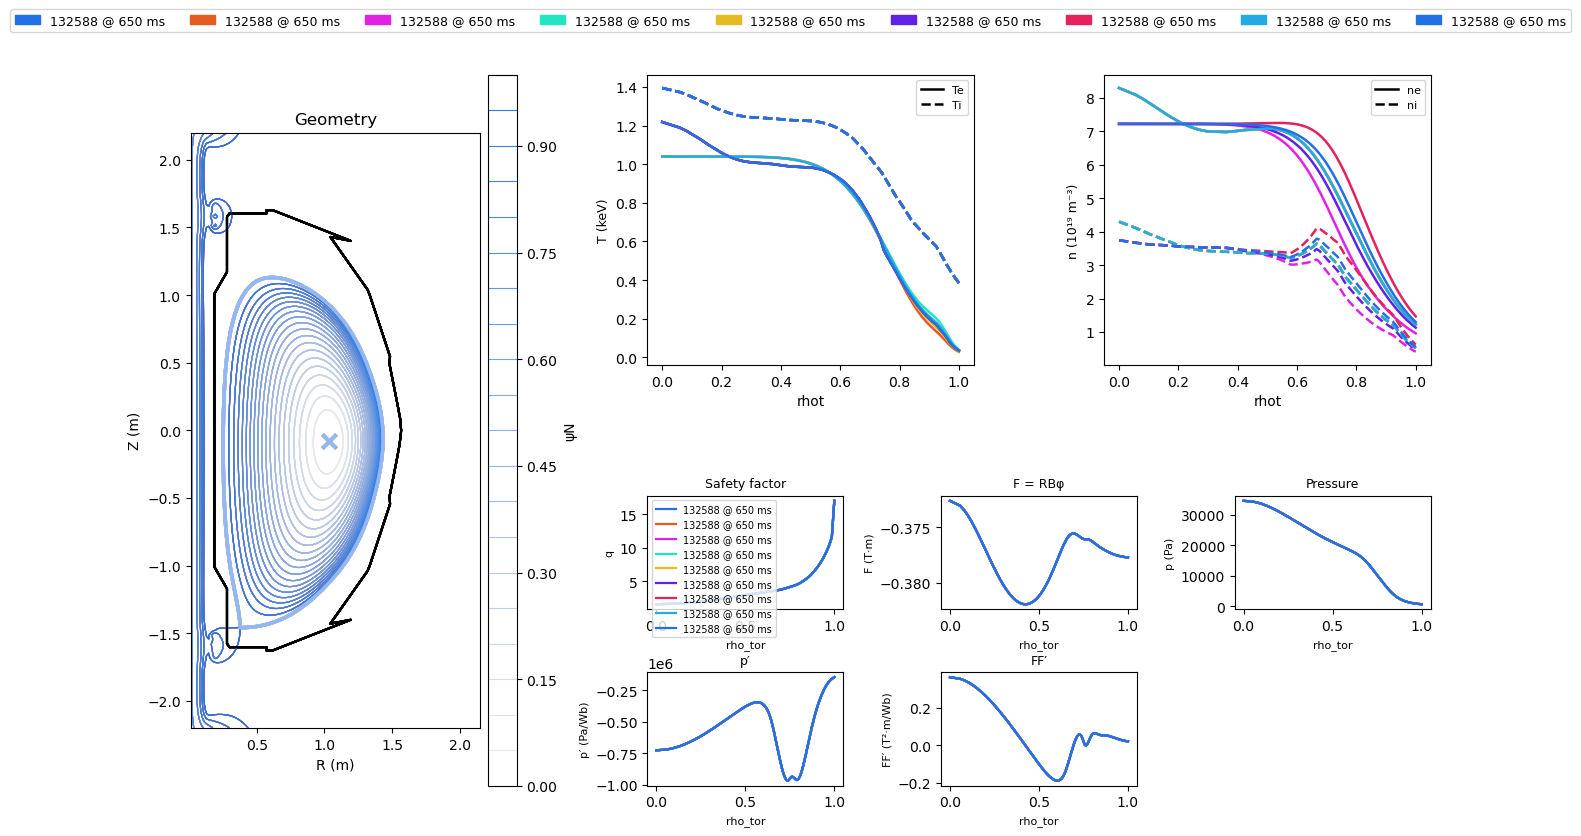

/tmp/ipykernel_92933/1737075941.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


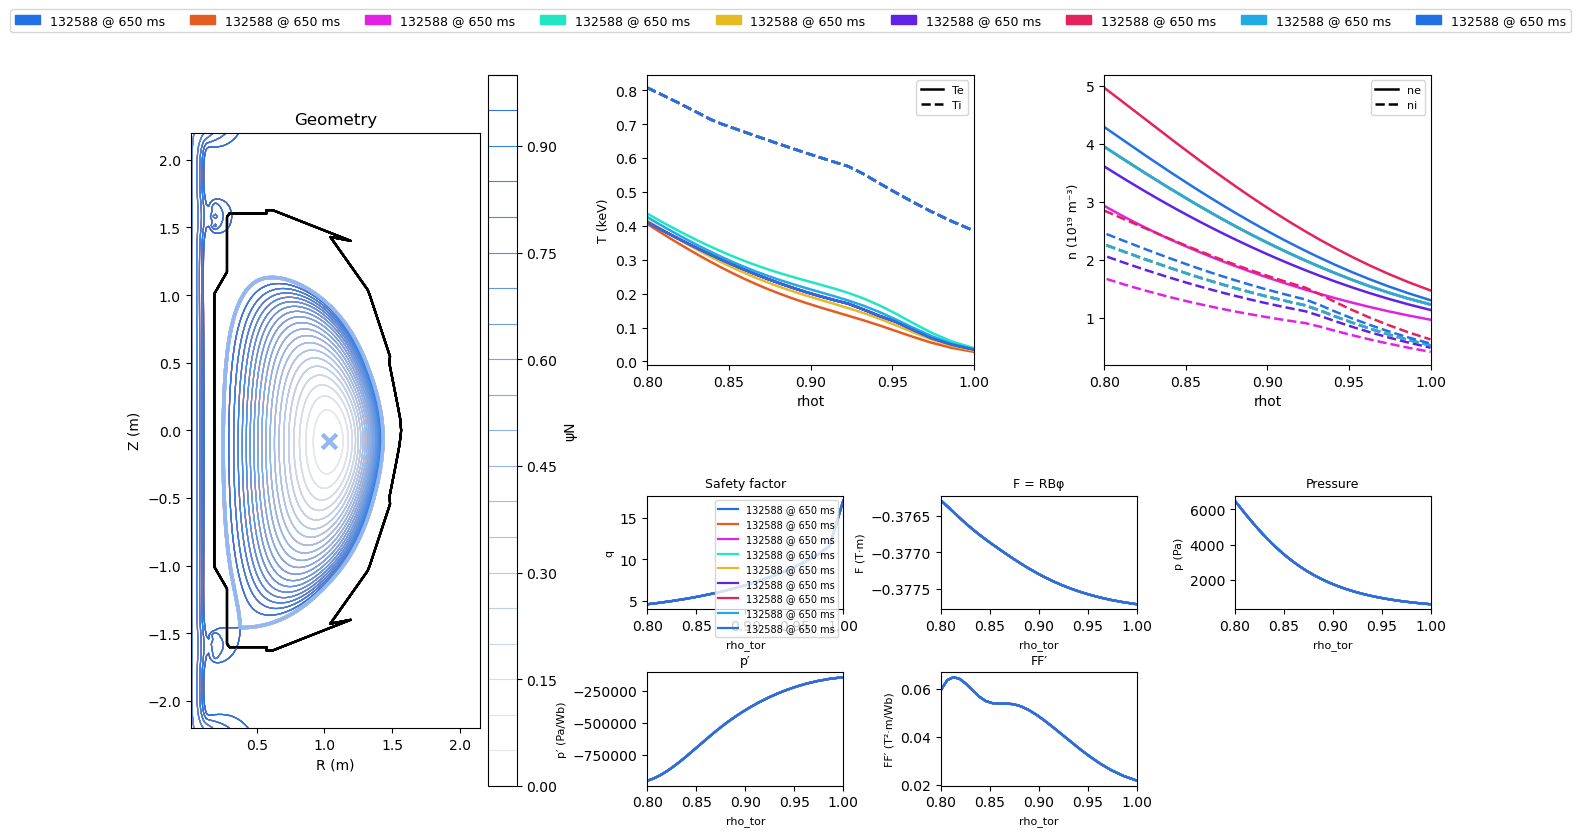

In [20]:
VARS = ("Te", "Ti", "ne", "ni")

# --- Full profiles ---
fig = phys_129015_base.plot(vars=VARS)
for phys in phys_list:
    fig = phys.plot(vars=VARS, fig=fig)
# fig = phys5.plot(vars=VARS, fig=fig)
plt.tight_layout()
plt.show()

# --- Zoomed: pedestal region ---
fig = phys_129015_base.plot(vars=VARS, rho_tor=[0.8, 1])
for phys in phys_list:
    fig = phys.plot(vars=VARS, rho_tor=[0.8, 1], fig=fig)
plt.tight_layout()
plt.show()

# Discharge scaling

Demonstrates profile transforms (`apply_mtanh_ped`, `apply_omne`) with two plot views:
- **Full profiles** — full radial domain
- **Zoomed (pedestal)** — restricted to `rho_tor=[0.8, 1]`

In [ ]:
phys3_omne = DischargePhysics(discharge3).apply_omne(alpha=0.5, rhot_midped=0.93, rhot_topped=0.80)
phys3_mtanh = DischargePhysics(discharge3).apply_mtanh_ped(["Te", "ne"], scale_width=1.2)

VARS = ("Te", "Ti", "ne", "ni")

# --- Full profiles ---
fig = phys3.plot(vars=VARS)
fig = phys3_mtanh.plot(vars=VARS, fig=fig)
plt.tight_layout()
plt.show()

# --- Zoomed: pedestal region ---
fig = phys3.plot(vars=VARS, rho_tor=[0.8, 1])
fig = phys3_mtanh.plot(vars=VARS, fig=fig)
plt.tight_layout()
plt.show()

## Geometry only

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))
phys.plot_geometry(ax=ax)
plt.tight_layout()
plt.show()

## Canonical profiles (harmonized)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, var in zip(axes, ["Te", "Ti", "ne", "ni"]):
    phys.plot_profiles([var], ax=ax)
plt.tight_layout()
plt.show()

## Raw gfile 1D profiles

In [ ]:
fig = phys.plot_gfile()
plt.tight_layout()
plt.show()

## Raw pfile profiles

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
phys.plot_pfile(vars=("Te", "Ti", "ne"), ax=ax)
plt.tight_layout()
plt.show()

## Multi-discharge comparison

Pass the same  to overlay two discharges.

In [ ]:
fig = phys.plot_profiles(["Te", "ne"])
fig = phys2.plot_profiles(["Te", "Ti", "ne", "ni"], fig=fig, rho_tor=[0.7,1])
fig = phys3.plot_profiles(["Te", "ne"], fig=fig)
plt.tight_layout()
plt.show()

## Harmonized vs raw pfile overlay

Use dashed raw pfile on same axes to spot harmonization artefacts.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
phys.plot_profiles(["Te"], ax=ax, label="harmonized")
phys.plot_pfile(vars=("Te",), ax=ax, label="raw pfile")
ax.set_title("Te: harmonized vs raw pfile")
plt.tight_layout()
plt.show()